# Ingest zip codes geo-locations

Anton Antonov   
May 2026

---

## Introduction

This notebook demonstrates the usage of the functions `hextile_bins`, `hextile_histogram`, `tile_bins`, and `tile_histogram` provided by the Python package ["TileStats"](https://pypi.org/project/TileStats/), [AAp1], over the geographical points corresponding to USA ZIP codes and populations data over USA ZIP codes.

----

## Setup

In this package relevant packages are loaded and plot parameters are setup.

In [64]:
import math
import os
import random
import sys

import pandas as pd
from DataTypeSystem import *

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl


# Make the local package importable without installation
#sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

from TileStats import (
    hextile_bins,
    hextile_histogram,
    tile_bins,
    tile_histogram,
)

Plot styling variables:

In [65]:
points_color = '#2b6cb0'
hextile_cmap = 'Grays'
tile_cmap = 'Greens'
plot_bg = '#1f1f1f'
figure_bg = '#1f1f1f'

mpl.rcParams.update({
    "axes.edgecolor": "silver",
    "axes.labelcolor": "silver",
    "xtick.color": "silver",
    "ytick.color": "silver",
    "text.color": "silver",
})

Special color functions:

In [66]:
black_blue = LinearSegmentedColormap.from_list(
    "black_blue",
    ["#2F2F2F", "#0000ff"]
)

This makes the library "matplotlib" to output SVG images (makes it easier to export the notebook to Markdown):

In [4]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

In [16]:
%load_ext JupyterChatbook

-----

## Ingest data

Generate random 2D data points:

In [79]:
%%chat -i=python
how to set the figure size of ax?

```python
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
```

In [24]:
url = "https://raw.githubusercontent.com/antononcube/SystemModeling/refs/heads/master/Data/dfUSZipCodesFrom2013GovernmentData.csv"
dfZipLatLon = pd.read_csv(url, dtype={"ZIP": 'string', "LAT": "float64", "LON": "float64"})

In [40]:
dfZipLatLon.describe()

,LAT,LON
count,33144.000000,33144.000000
mean,38.819930,-90.924452
std,5.391254,15.787902
min,13.260372,-176.629994
25%,35.389437,-97.234251
50%,39.493230,-88.192612
75%,42.120854,-80.219373
max,71.253500,145.754437


----

## ZIP codes map

Only "reasonable" ZIP code points:

In [50]:
dfZipLatLon = dfZipLatLon[
    (dfZipLatLon["LON"] >= -140) & (dfZipLatLon["LON"] <= -60) &
    (dfZipLatLon["LAT"] >= 20) & (dfZipLatLon["LAT"] <= 50)
]
dfZipLatLon.shape

(32657, 3)

In [51]:
xs = dfZipLatLon["LON"].to_list()
ys = dfZipLatLon["LAT"].to_list()

In [55]:
plt.figure(figsize=(16, 8))
plt.scatter(xs, ys, s=2, alpha=0.6, color=points_color)
plt.title('USA ZIP codes')
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
ax.set_facecolor(plot_bg)
ax.figure.set_facecolor(figure_bg)
#plt.show()

----

## Hextile bins

Hextile bins (center keys):

In [67]:
data = list(zip(xs, ys))
hextile_bins = hextile_bins(data, bin_size=0.6, polygon_keys=False)

Show a few bin centers and counts:

In [68]:
list(hextile_bins.items())[:8]

[((-72.89999999999999, 42.08883462392371), 53),
 ((-72.6, 42.60844986619438), 47),
 ((-72.0, 42.60844986619438), 34),
 ((-72.3, 42.08883462392371), 57),
 ((-73.2, 42.60844986619438), 36),
 ((-73.5, 42.08883462392371), 42),
 ((-71.39999999999999, 42.60844986619438), 73),
 ((-71.7, 42.08883462392371), 77)]

Hextile histogram (colored polygons):

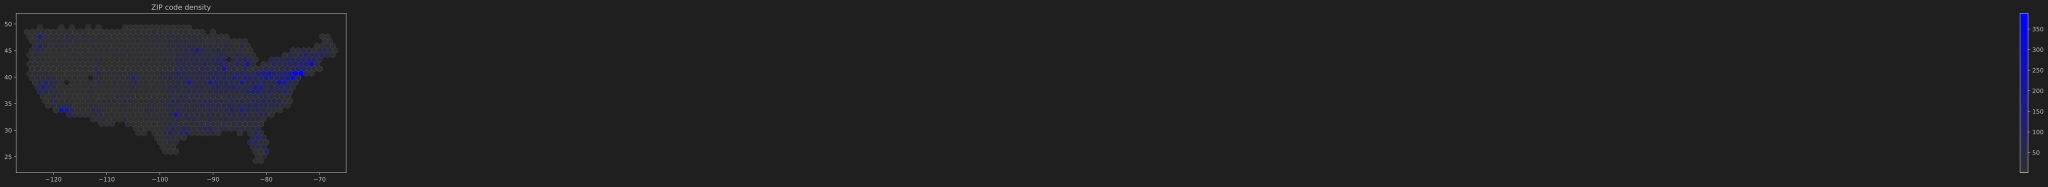

In [98]:
args_dict = {
    "title": "ZIP code density",
    "bin_size": 1,
    "data_range": ((-127, -65), (22, 52)),
    "histogram_type": "ColoredPolygons",
    "overlap_factor": 1,
    "edge_color": "DimGray",
    "line_width": 0.2,
    "plot": True,
    "plot_legends": "Automatic",
    "color_function": black_blue,  # hextile_cmap,
    "facecolor": plot_bg
}

geo_hist = hextile_histogram(data, **args_dict)
geo_hist['figure'].set_facecolor(plot_bg)
geo_hist['figure'].set_figwidth(1000)

-----

## Mapping USA counties populations

Using the function `hextile_histogram` in this section we visualize USA county populations over a hexagonal grid with cell radius 2 degrees (≈ 140 miles, ≈222 kilometers.)
Here we ingest the populations data (provided by [[AAr1](https://github.com/antononcube/SystemModeling)]):

In [89]:
url = 'https://raw.githubusercontent.com/antononcube/SystemModeling/refs/heads/master/Data/dfUSACountyRecords.csv'
df = pd.read_csv(url)

Filter the geo-spatial data to be within certain boundaries and show its structure:

In [90]:
populations = {(lon, lat): pop for lat, lon, pop in zip(df["Lat"], df["Lon"], df["Population"]) if lon > -135 and 20 <= lat and lat <= 55}
deduce_type(populations)


Assoc(Pair(Atom(<class 'float'>), Atom(<class 'float'>)), Atom(<class 'int'>), 3109)

Make the geo-spatial histogram (that consists of hexagons):

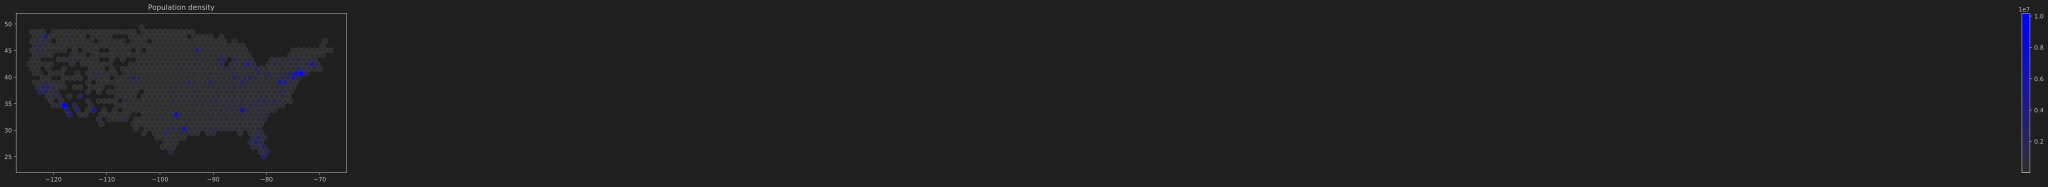

In [99]:
args_dict = {
    "title": "Population density",
    "bin_size": 1,
    "data_range": ((-127, -65), (22, 52)),
    "histogram_type": "ColoredPolygons",
    "overlap_factor": 1,
    "edge_color": "DimGray",
    "line_width": 0.2,
    "plot": True,
    "plot_legends": "Automatic",
    "color_function": black_blue,  # hextile_cmap,
    "facecolor": plot_bg
}

geo_hist = hextile_histogram(populations, **args_dict)
geo_hist['figure'].set_facecolor(plot_bg)
geo_hist['figure'].set_figwidth(1000)

Here is the corresponding square tile histogram:

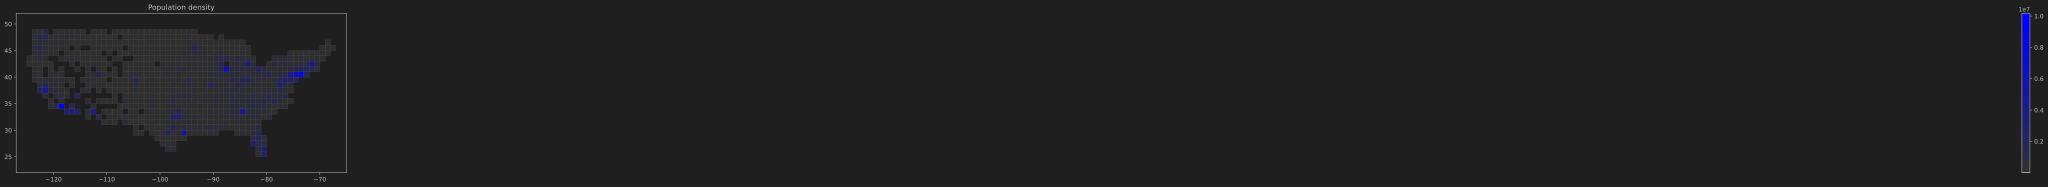

In [100]:
geo_hist = tile_histogram(populations, **args_dict)
geo_hist['figure'].set_facecolor(plot_bg)
geo_hist['figure'].set_figwidth(1000)

----

## References

### Articles, blog posts

[AA1] Anton Antonov, ["A monad for Epidemiologic Compartmental Modeling Workflows"](https://mathematicaforprediction.wordpress.com/2021/01/02/epidemiology-compartmental-modeling-monad/), (2021), [MathematicaForPrediction at WordPress](https://mathematicaforprediction.wordpress.com).

### Packages 

[AAp1] Anton Antonov, [TileStats, Python package](https://pypi.org/project/TileStats), (2026), [PyPI.org](https://pypi.org).

[AAp2] Anton Antonov, [TileStats, Wolfram Language paclet](https://resources.wolframcloud.com/PacletRepository/resources/AntonAntonov/TileStats/), (2023), [Wolfram Language Paclet Repository](https://resources.wolframcloud.com/PacletRepository).

[AAp3] Anton Antonov, [TileStats, Java package](https://github.com/antononcube/Java-TileStats), (2023), [GitHub/antononcube](https://github.com/antononcube).

### Repositories

[AAr1] Anton Antonov, [SystemModeling](https://github.com/antononcube/SystemModeling), (2020-2025), [GitHub/antononcube](https://github.com/antononcube).